Configuration:
  Stocks: AAPL, GOOGL, MSFT, AMZN, TSLA
  Date Range: 2020-01-01 to 2024-12-31

Task 1: Downloading stock data...
  AAPL: 1257 records
  GOOGL: 1257 records
  MSFT: 1257 records
  AMZN: 1257 records
  TSLA: 1257 records
Downloaded: 5/5 stocks

Task 2-3: Cleaning data and computing returns...
  AAPL: mean=0.000998, std=0.019952
  GOOGL: mean=0.000826, std=0.020501
  MSFT: mean=0.000820, std=0.019238
  AMZN: mean=0.000684, std=0.022666
  TSLA: mean=0.002110, std=0.042221

Task 4: Combining stocks...
  Combined shape: (6280, 9)
  Date range: 2020-01-03 to 2024-12-30

  Saved combined dataset (6280 rows)

Creating visualization...
  Visualization saved



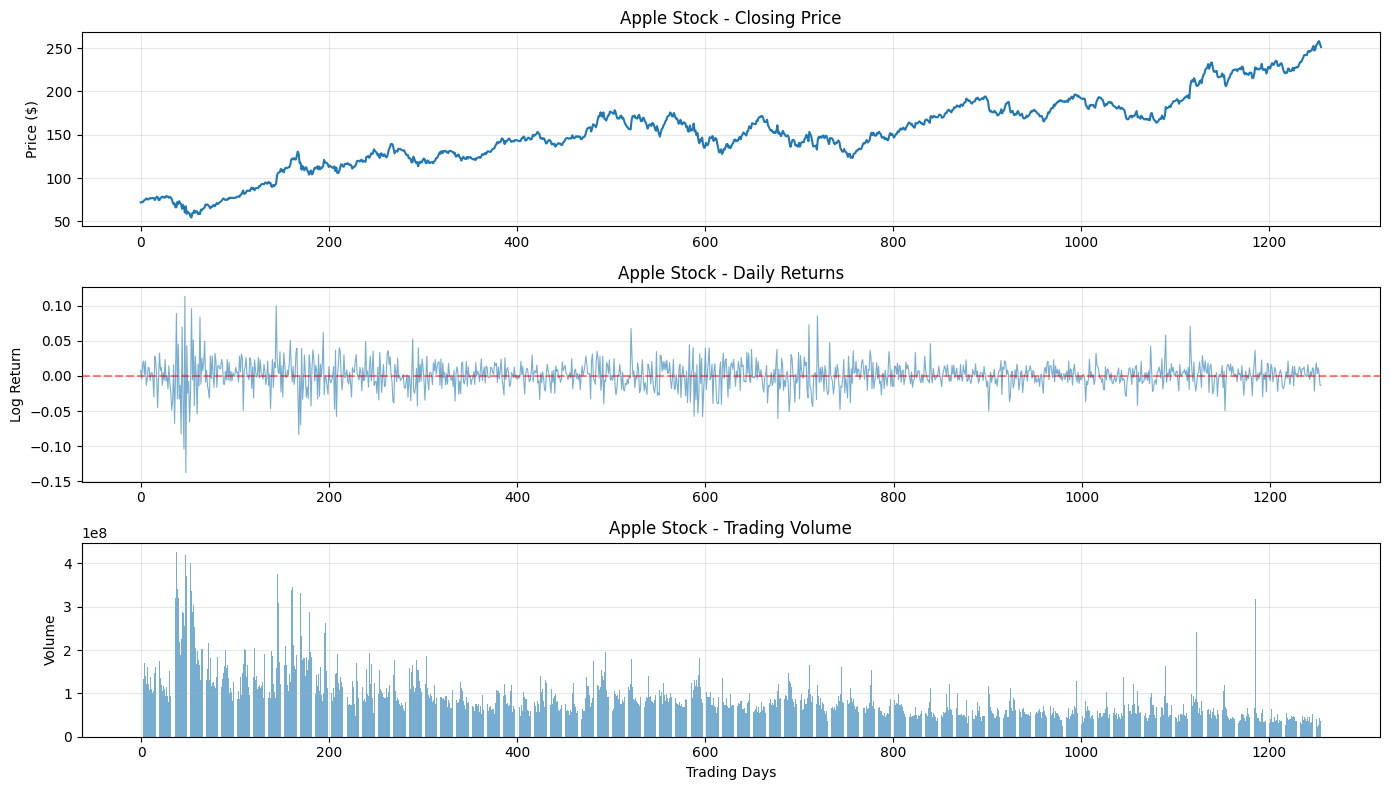

Data quality validation:
  Missing values: 0
  Return mean: 0.001088
  Return std: 0.026397
  Output files verified: True

Data Preprocessing Complete
Processed 5 stocks with 6280 total records
Date range: 2020-01-01 to 2024-12-31
Output directory: data/processed/


In [1]:
# ============================================================================
# Stock Market Data Preprocessing Pipeline
# 
# Author: Ngoc Vo
# Date: October 2024
# Purpose: Preprocess stock market data for ML model training
# ============================================================================

# ============================================================================
# Import Libraries
# ============================================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings('ignore')

# ============================================================================
# Configuration
# ============================================================================

# Force working directory to project root
PROJECT_ROOT = r'C:\Users\ngocv\Desktop\Stock-Treadliner'
os.chdir(PROJECT_ROOT)

STOCK_LIST = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']
START_DATE = '2020-01-01'
END_DATE = '2024-12-31'
OUTPUT_DIR = 'data/processed'

print("Configuration:")
print(f"  Stocks: {', '.join(STOCK_LIST)}")
print(f"  Date Range: {START_DATE} to {END_DATE}\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================================
# Preprocessing Function
# ============================================================================

def preprocess_data(stock_df, symbol, output_path):
    """
    Preprocess stock data for machine learning.
    
    Parameters:
    -----------
    stock_df : DataFrame
        Raw stock data from yfinance with OHLCV columns
    symbol : str
        Stock ticker symbol
    output_path : str
        Path to save the preprocessed CSV file
        
    Returns:
    --------
    DataFrame : Preprocessed stock data with returns calculated
    """
    # Keep only OHLCV columns
    df = stock_df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.columns = ['open', 'high', 'low', 'close', 'volume']
    
    # Clean date format: convert index to simple date string
    df['date'] = pd.to_datetime(df.index).date
    df['date'] = df['date'].astype(str)
    df = df.reset_index(drop=True)
    
    # Reorder columns: date first
    df = df[['date', 'open', 'high', 'low', 'close', 'volume']]
    
    # Handle missing values in price columns
    price_cols = ['open', 'high', 'low', 'close', 'volume']
    missing_count = df[price_cols].isnull().sum().sum()
    if missing_count > 0:
        df[price_cols] = df[price_cols].fillna(method='ffill').fillna(method='bfill')
    
    # Add symbol identifier
    df['symbol'] = symbol
    
    # Calculate log returns
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))
    
    # Calculate next-day return (target variable)
    df['next_day_return'] = df['log_return'].shift(-1)
    
    # Drop first row with NaN in log_return
    df = df.dropna(subset=['log_return'])
    
    # Save to CSV
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    df.to_csv(output_path, index=False)
    
    return df

# ============================================================================
# Task 1: Collect Daily OHLCV Data
# ============================================================================

print("Task 1: Downloading stock data...")

raw_data = {}

for symbol in STOCK_LIST:
    try:
        ticker = yf.Ticker(symbol)
        data = ticker.history(start=START_DATE, end=END_DATE)
        
        if not data.empty:
            raw_data[symbol] = data
            print(f"  {symbol}: {len(data)} records")
    except Exception as e:
        print(f"  {symbol}: Error - {e}")

print(f"Downloaded: {len(raw_data)}/{len(STOCK_LIST)} stocks\n")

# ============================================================================
# Task 2-3: Clean Data and Compute Returns
# ============================================================================

print("Task 2-3: Cleaning data and computing returns...")

cleaned_data = {}

for symbol, raw_df in raw_data.items():
    output_path = f'{OUTPUT_DIR}/{symbol}_cleaned.csv'
    cleaned_df = preprocess_data(raw_df, symbol, output_path)
    cleaned_data[symbol] = cleaned_df
    
    returns = cleaned_df['next_day_return'].dropna()
    print(f"  {symbol}: mean={returns.mean():.6f}, std={returns.std():.6f}")

print()

# ============================================================================
# Task 4: Combine Stocks
# ============================================================================

print("Task 4: Combining stocks...")

# Combine all cleaned data
combined_data = pd.concat(cleaned_data.values(), axis=0, ignore_index=True)
combined_data = combined_data.sort_values(['date', 'symbol']).reset_index(drop=True)

print(f"  Combined shape: {combined_data.shape}")
print(f"  Date range: {combined_data['date'].min()} to {combined_data['date'].max()}\n")

# Save combined dataset
combined_path = f'{OUTPUT_DIR}/combined_stock_data.csv'
combined_data.to_csv(combined_path, index=False)
print(f"  Saved combined dataset ({len(combined_data)} rows)\n")

# ============================================================================
# Create Visualization
# ============================================================================

print("Creating visualization...")

if 'AAPL' in cleaned_data:
    apple_data = cleaned_data['AAPL']
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 8))
    
    # Price chart
    axes[0].plot(range(len(apple_data)), apple_data['close'], linewidth=1.5)
    axes[0].set_title('Apple Stock - Closing Price', fontsize=12)
    axes[0].set_ylabel('Price ($)')
    axes[0].grid(True, alpha=0.3)
    
    # Returns chart
    axes[1].plot(range(len(apple_data)), apple_data['next_day_return'], 
                 alpha=0.6, linewidth=0.8)
    axes[1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
    axes[1].set_title('Apple Stock - Daily Returns', fontsize=12)
    axes[1].set_ylabel('Log Return')
    axes[1].grid(True, alpha=0.3)
    
    # Volume chart
    axes[2].bar(range(len(apple_data)), apple_data['volume'], alpha=0.6)
    axes[2].set_title('Apple Stock - Trading Volume', fontsize=12)
    axes[2].set_ylabel('Volume')
    axes[2].set_xlabel('Trading Days')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    viz_path = f'{OUTPUT_DIR}/stock_visualization.png'
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"  Visualization saved\n")
    plt.show()

# ============================================================================
# Data Quality Validation
# ============================================================================

print("Data quality validation:")

# Check missing values
missing = combined_data[['open', 'high', 'low', 'close', 'volume']].isnull().sum().sum()
print(f"  Missing values: {missing}")

# Check return statistics
all_returns = combined_data['next_day_return'].dropna()
print(f"  Return mean: {all_returns.mean():.6f}")
print(f"  Return std: {all_returns.std():.6f}")

# Verify output files
files_verified = all([
    os.path.exists(f'{OUTPUT_DIR}/combined_stock_data.csv'),
    os.path.exists(f'{OUTPUT_DIR}/AAPL_cleaned.csv'),
    os.path.exists(f'{OUTPUT_DIR}/GOOGL_cleaned.csv'),
    os.path.exists(f'{OUTPUT_DIR}/MSFT_cleaned.csv'),
    os.path.exists(f'{OUTPUT_DIR}/AMZN_cleaned.csv'),
    os.path.exists(f'{OUTPUT_DIR}/TSLA_cleaned.csv'),
])
print(f"  Output files verified: {files_verified}\n")

# ============================================================================
# Summary
# ============================================================================

print("="*70)
print("Data Preprocessing Complete")
print("="*70)
print(f"Processed {len(STOCK_LIST)} stocks with {len(combined_data)} total records")
print(f"Date range: {START_DATE} to {END_DATE}")
print(f"Output directory: data/processed/")
print("="*70)